# D2C3 — convolutional networks on Irish weather data

STAT41140: AI for weather and climate. Companion notebook for the deep-learning and CNN lecture.

We forecast **Dublin's 2 m temperature one hour ahead** from a 24-hour history of temperature and
wind at Dublin, Galway and Cork.

The single most important idea in this notebook is not the convolution. It is this:

> **A forecast model is worthless until it beats a baseline you can compute without it.**

For hourly temperature the baseline is **persistence** — assume the temperature will not change.
It is embarrassingly hard to beat, and we will fail to beat it twice before we succeed.

What we do:

1. load the data and split it **chronologically**
2. compute the persistence baseline, in degrees, before touching a model
3. build a 1D CNN — and watch it lose to persistence
4. work out why, fix it in two steps, and beat the baseline
5. extend to all three cities at once

**Data.** Put `era5_ireland3_t2m_wind_2024.csv` next to this notebook, or edit `CSV_PATH` below.
If the file is missing, the notebook generates a clearly-labelled synthetic stand-in so that
everything still runs — but the numbers will not be the real ones, and the notebook says so loudly.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

plt.rcParams.update({"figure.figsize": (10, 3.4), "figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGS = Path("figs_d2c3"); FIGS.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

CSV_PATH = Path("era5_ireland3_t2m_wind_2024.csv")

COLS = ['Dublin_t2m_degC', 'Galway_t2m_degC', 'Cork_t2m_degC',
        'Dublin_wind_speed10m_ms', 'Galway_wind_speed10m_ms', 'Cork_wind_speed10m_ms']
TARGET = 'Dublin_t2m_degC'


def make_surrogate(n=8784, seed=11):
    '''A stand-in with the right shape and roughly the right statistics. NOT real data.'''
    rng = np.random.default_rng(seed)
    t = np.arange(n); doy = t / 24.0

    def ar1(rho, sd):
        e = np.zeros(n); z = rng.normal(0, sd, n)
        for i in range(1, n):
            e[i] = rho * e[i - 1] + z[i]
        return e

    common = ar1(0.98, 0.55)                      # shared synoptic variability
    out = {"time": pd.date_range("2024-01-01", periods=n, freq="h")}
    for city, base, samp, damp in [("Dublin", 10.2, 5.0, 2.4),
                                   ("Galway", 10.6, 4.4, 2.0),
                                   ("Cork",   10.8, 4.6, 2.2)]:
        out[f"{city}_t2m_degC"] = (base
                                   + samp * np.sin(2 * np.pi * (doy - 80) / 366)   # seasonal
                                   + damp * np.sin(2 * np.pi * (t / 24.0 - 9))     # diurnal
                                   + common + ar1(0.95, 0.25) + rng.normal(0, 0.12, n))
    for city, base in [("Dublin", 6.4), ("Galway", 7.2), ("Cork", 5.9)]:
        out[f"{city}_wind_speed10m_ms"] = np.abs(base + ar1(0.97, 1.1) + rng.normal(0, 0.4, n))
    return pd.DataFrame(out)


if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH, parse_dates=['time'])
    USING_REAL_DATA = True
else:
    df = make_surrogate()
    USING_REAL_DATA = False
    print("!" * 78)
    print("!!  era5_ireland3_t2m_wind_2024.csv NOT FOUND — using a SYNTHETIC stand-in.")
    print("!!  The code is identical, but every number below is from simulated data.")
    print("!!  Put the real CSV next to this notebook and re-run to get the real answers.")
    print("!" * 78)

df = df.sort_values('time').reset_index(drop=True)
print(f"\n{len(df)} rows, {df['time'].min()} to {df['time'].max()}")
df.head()


8784 rows, 2024-01-01 00:00:00 to 2024-12-31 23:00:00


,time,Dublin_t2m_degC,Galway_t2m_degC,Cork_t2m_degC,Dublin_wind_speed10m_ms,Galway_wind_speed10m_ms,Cork_wind_speed10m_ms
0,2024-01-01 00:00:00,5.763580,6.396393,5.617096,8.426119,6.120335,4.927529
1,2024-01-01 01:00:00,5.445953,5.922516,5.094391,8.082199,5.639297,4.454760
2,2024-01-01 02:00:00,5.434723,5.518707,4.604645,7.943061,4.928046,3.922362
3,2024-01-01 03:00:00,5.265533,5.257721,4.111237,7.585234,4.344268,3.177118
4,2024-01-01 04:00:00,5.138092,5.163483,3.917389,7.084112,3.941263,2.874048


## 1. Look at the data first

Always. Ten minutes here saves a day of debugging a model that was fitting a units error.

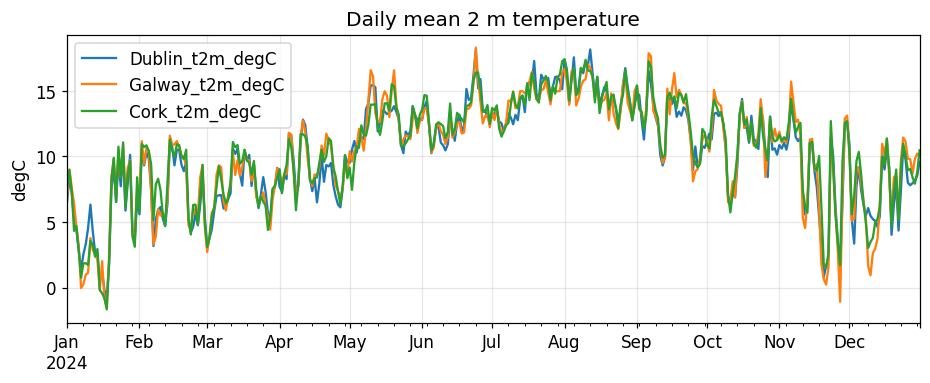

                          mean   std   min    max
Dublin_t2m_degC          10.29  4.28 -3.02  21.84
Galway_t2m_degC          10.40  4.52 -4.38  23.88
Cork_t2m_degC            10.53  4.35 -4.25  22.44
Dublin_wind_speed10m_ms   4.51  2.18  0.09  15.25
Galway_wind_speed10m_ms   4.22  2.12  0.04  16.09
Cork_wind_speed10m_ms     4.00  1.96  0.09  14.37

correlation between the three temperatures:
                 Dublin_t2m_degC  Galway_t2m_degC  Cork_t2m_degC
Dublin_t2m_degC            1.000            0.943          0.951
Galway_t2m_degC            0.943            1.000          0.955
Cork_t2m_degC              0.951            0.955          1.000


In [2]:
fig, ax = plt.subplots()
daily = df.set_index('time')[['Dublin_t2m_degC', 'Galway_t2m_degC', 'Cork_t2m_degC']].resample('1D').mean()
daily.plot(ax=ax)
ax.set_title("Daily mean 2 m temperature" + ("" if USING_REAL_DATA else "  [SYNTHETIC DATA]"))
ax.set_ylabel("degC"); ax.set_xlabel("")
fig.savefig(FIGS / "d2c3_fig01_series.png"); plt.show()

print(df[COLS].describe().round(2).T[['mean', 'std', 'min', 'max']])
print("\ncorrelation between the three temperatures:")
print(df[['Dublin_t2m_degC', 'Galway_t2m_degC', 'Cork_t2m_degC']].corr().round(3))

The three cities are very strongly correlated — which is exactly why forecasting Dublin from
Galway and Cork is plausible, and also why it is not as impressive as it first sounds.

## 2. Split by time, never at random

Consecutive hours are almost the same. A random split puts the 3 p.m. reading in training and the
4 p.m. reading in test, so the model can very nearly look up the answer. Every score then flatters.
Split chronologically.

In [3]:
n = len(df)
i_tr, i_va = int(0.70 * n), int(0.85 * n)
train_df, val_df, test_df = df.iloc[:i_tr], df.iloc[i_tr:i_va], df.iloc[i_va:]

print(f"train {len(train_df):>5} rows  {train_df['time'].min().date()} to {train_df['time'].max().date()}")
print(f"val   {len(val_df):>5} rows  {val_df['time'].min().date()} to {val_df['time'].max().date()}")
print(f"test  {len(test_df):>5} rows  {test_df['time'].min().date()} to {test_df['time'].max().date()}")

train  6148 rows  2024-01-01 to 2024-09-13
val    1318 rows  2024-09-13 to 2024-11-07
test   1318 rows  2024-11-07 to 2024-12-31


### Scaling: statistics from the training set only

Fitting the scaler on the whole file leaks information about the test period into training. It is
a small effect here and a fatal one in a research paper, and it is the single easiest way to
publish a result that will not replicate.

In [4]:
mu = train_df[COLS].values.mean(axis=0)      # TRAINING set only
sd = train_df[COLS].values.std(axis=0)
print("means (train):", np.round(mu, 2))
print("sds   (train):", np.round(sd, 2))

means (train): [10.64 10.69 10.78  4.46  4.24  4.  ]
sds   (train): [4.47 4.59 4.55 2.1  2.06 1.85]


## 3. The persistence baseline, in degrees

Before any model. $\hat{y}_{t+1} = y_t$: tomorrow's hour is the same as this one.

In [5]:
T = 24        # hours of history each sample sees


def build(frame, predict_change):
    '''Return (X, y, last, y_absolute) for one time-ordered frame.

    X    : (N, 6, T)  scaled inputs, channels-first, as Conv1d wants
    y    : (N,)       what the model is asked to predict
    last : (N,)       the most recent observed Dublin temperature — the persistence forecast
    '''
    F = (frame[COLS].values - mu) / sd
    target = frame[TARGET].values
    X, last, y_abs = [], [], []
    for t in range(len(frame) - T):
        X.append(F[t:t + T].T)
        last.append(target[t + T - 1])
        y_abs.append(target[t + T])
    X = np.stack(X).astype(np.float32)
    last = np.array(last, dtype=np.float32)
    y_abs = np.array(y_abs, dtype=np.float32)
    y = (y_abs - last) if predict_change else y_abs
    return X, y, last, y_abs


_, _, last_te, yabs_te = build(test_df, predict_change=False)
PERSISTENCE = float(np.sqrt(np.mean((last_te - yabs_te) ** 2)))

print(f"persistence RMSE on the test set: {PERSISTENCE:.4f} degC")
print("Any model that cannot beat this number is not worth deploying.")

persistence RMSE on the test set: 0.4539 degC
Any model that cannot beat this number is not worth deploying.


## 4. Attempt 1 — a 1D CNN that loses

Two convolution layers, then a global average pool, then one linear layer. This is the textbook
shape and it is what both of the notebooks this one replaces used.

In [6]:
def make_cnn(head):
    '''Two Conv1d layers over the 24-hour window, then whatever head we hand it.'''
    return nn.Sequential(
        nn.Conv1d(6, 16, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
        head,
    )


POOLED_HEAD  = lambda: nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(32, 1))
FLATTEN_HEAD = lambda: nn.Sequential(nn.Flatten(), nn.Linear(32 * T, 32), nn.ReLU(),
                                     nn.Linear(32, 1))


def fit_and_score(head_fn, predict_change, epochs=25, seed=0, label=""):
    '''Train on train, early-stop on val, report RMSE in degC on test.'''
    torch.manual_seed(seed)
    Xtr, ytr, _, _ = build(train_df, predict_change)
    Xva, yva, _, _ = build(val_df,   predict_change)
    Xte, _, last, yabs = build(test_df, predict_change)

    ys = ytr.std()                                   # scale the target for stable training
    Xt = torch.tensor(Xtr); yt = torch.tensor(ytr / ys).unsqueeze(1)
    Xv = torch.tensor(Xva); yv = torch.tensor(yva / ys).unsqueeze(1)

    model = make_cnn(head_fn())
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossfn = nn.MSELoss()
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, yt),
                                         batch_size=64, shuffle=True)

    best, best_state, curve = np.inf, None, []
    for ep in range(epochs):
        model.train()                                # dropout/batchnorm ON (none here, but habit)
        for xb, yb in loader:
            opt.zero_grad(); lossfn(model(xb), yb).backward(); opt.step()
        model.eval()                                 # and OFF for evaluation
        with torch.no_grad():
            v = lossfn(model(Xv), yv).item()
        curve.append(v)
        if v < best:
            best, best_state = v, {k: t.clone() for k, t in model.state_dict().items()}

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        out = model(torch.tensor(Xte)).squeeze(1).numpy() * ys
    pred = last + out if predict_change else out
    rmse = float(np.sqrt(np.mean((pred - yabs) ** 2)))
    n_par = sum(p.numel() for p in model.parameters())
    print(f"{label:<38} test RMSE = {rmse:6.4f} degC   ({n_par:,} parameters)")
    return rmse, pred, yabs, curve


rmse_pooled, *_ = fit_and_score(POOLED_HEAD, predict_change=False,
                                label="1) conv -> global average pool")
print(f"{'persistence baseline':<38} test RMSE = {PERSISTENCE:6.4f} degC")

1) conv -> global average pool         test RMSE = 1.6260 degC   (1,905 parameters)
persistence baseline                   test RMSE = 0.4539 degC


Comfortably worse than doing nothing at all.

> **Question for the room:** the network has thousands of parameters and 24 hours of data from
> three cities. Persistence has no parameters and looks at one number. How is it losing?

**Because of the global average pool.** It takes the 32 feature channels and averages each one
over all 24 hours, so a pattern at hour 3 and the same pattern at hour 23 produce identical
output. For a *next-hour* forecast, the last hour is nearly the whole signal — and we have just
thrown away which hour was which.

## 5. Attempt 2 — keep the time axis

In [7]:
rmse_flat, *_ = fit_and_score(FLATTEN_HEAD, predict_change=False,
                              label="2) conv -> flatten (keeps time order)")
print(f"{'persistence baseline':<38} test RMSE = {PERSISTENCE:6.4f} degC")

2) conv -> flatten (keeps time order)  test RMSE = 0.4730 degC   (26,513 parameters)
persistence baseline                   test RMSE = 0.4539 degC


Much better, and still not good enough. The model now knows *when* things happened, but it is
being asked to produce the temperature from scratch — to rediscover, from six scaled channels, that
the answer is "about 11 degrees" before it can even start being useful.

## 6. Attempt 3 — predict the *change*, not the level

Give the model the one thing persistence already knows. Instead of asking for $y_{t+1}$, ask for

$$\Delta = y_{t+1} - y_t$$

and add it back to the last observation. The model now starts *at* persistence and only has to
learn the correction. This is the same move as working in anomalies in Class 1, and it is how
operational systems are built: model the departure, not the field.

In [8]:
rmse_delta, pred, yabs, curve = fit_and_score(FLATTEN_HEAD, predict_change=True,
                                              label="3) conv -> flatten, predict the CHANGE")
print(f"{'persistence baseline':<38} test RMSE = {PERSISTENCE:6.4f} degC")

skill = 100 * (1 - rmse_delta / PERSISTENCE)
print(f"\nskill score against persistence: {skill:.1f}% reduction in RMSE")

3) conv -> flatten, predict the CHANGE test RMSE = 0.3353 degC   (26,513 parameters)
persistence baseline                   test RMSE = 0.4539 degC

skill score against persistence: 26.1% reduction in RMSE


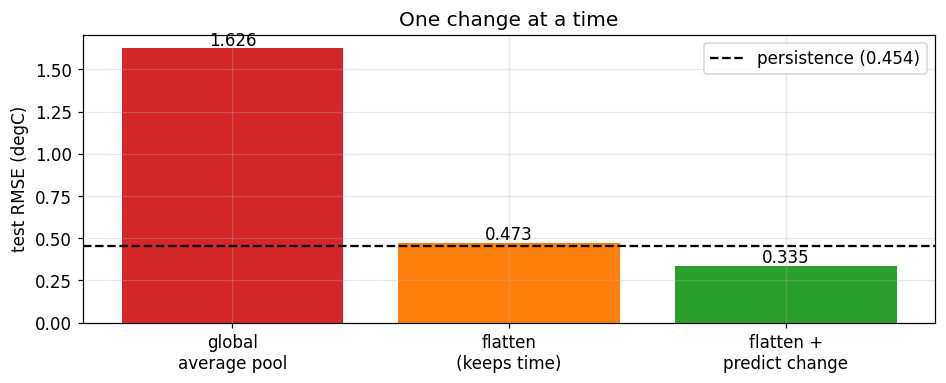

In [9]:
fig, ax = plt.subplots()
labels = ["global\naverage pool", "flatten\n(keeps time)", "flatten +\npredict change"]
vals = [rmse_pooled, rmse_flat, rmse_delta]
bars = ax.bar(labels, vals, color=["tab:red", "tab:orange", "tab:green"])
ax.axhline(PERSISTENCE, color="black", ls="--", lw=1.5, label=f"persistence ({PERSISTENCE:.3f})")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)
ax.set_ylabel("test RMSE (degC)")
ax.set_title("One change at a time" + ("" if USING_REAL_DATA else "  [SYNTHETIC DATA]"))
ax.legend()
fig.savefig(FIGS / "d2c3_fig02_ladder.png"); plt.show()

Three models, two changes, and only the third is worth anything. Note that the architecture is
identical in runs 2 and 3 — the same layers, the same parameter count. All that changed was **what
we asked it to predict**.

## 7. Does it look right?

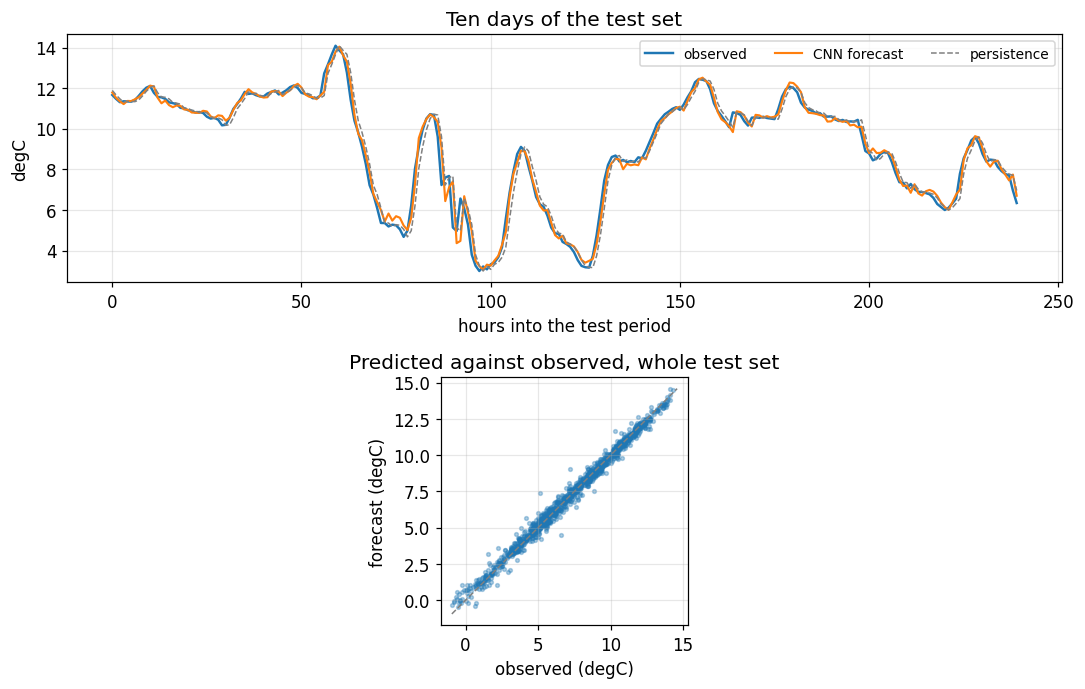

bias          : +0.0411 degC
RMSE          : 0.3353 degC
worst error   : 2.2690 degC


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.4))
k = 240
axes[0].plot(yabs[:k], label="observed", lw=1.6)
axes[0].plot(pred[:k], label="CNN forecast", lw=1.4)
axes[0].plot(last_te[:k], label="persistence", lw=1.0, ls="--", color="grey")
axes[0].set_ylabel("degC"); axes[0].set_xlabel("hours into the test period")
axes[0].set_title("Ten days of the test set"); axes[0].legend(ncol=3, fontsize=9)

lims = [min(yabs.min(), pred.min()), max(yabs.max(), pred.max())]
axes[1].plot(lims, lims, color="grey", ls="--", lw=1)
axes[1].scatter(yabs, pred, s=6, alpha=0.35)
axes[1].set_xlabel("observed (degC)"); axes[1].set_ylabel("forecast (degC)")
axes[1].set_title("Predicted against observed, whole test set")
axes[1].set_aspect("equal")

fig.tight_layout(); fig.savefig(FIGS / "d2c3_fig03_check.png"); plt.show()

resid = pred - yabs
print(f"bias          : {resid.mean():+.4f} degC")
print(f"RMSE          : {np.sqrt((resid**2).mean()):.4f} degC")
print(f"worst error   : {np.abs(resid).max():.4f} degC")

The scatter should hug the 1:1 line, and the bias should be near zero. A model with a visible tilt
in this plot is systematically over- or under-forecasting and needs looking at before anything else.

## 8. All three cities at once

The same machinery predicts a vector. We arrange the window as a small **spatio-temporal image**:

- 2 channels (temperature, wind)
- 24 rows (hours)
- 3 columns (Dublin, Galway, Cork)

so `Conv2d` filters can look across time *and* across cities at once. This is a genuine
$(2, 24, 3)$ tensor with nothing padded — every entry is a real observation.

In [11]:
CITY_T = ['Dublin_t2m_degC', 'Galway_t2m_degC', 'Cork_t2m_degC']
CITY_W = ['Dublin_wind_speed10m_ms', 'Galway_wind_speed10m_ms', 'Cork_wind_speed10m_ms']


def build_2d(frame):
    '''X: (N, 2, T, 3) = (temperature/wind, hours, cities). y: change in all three temps.'''
    temps = frame[CITY_T].values
    winds = frame[CITY_W].values
    mt, st = train_df[CITY_T].values.mean(0), train_df[CITY_T].values.std(0)
    mw, sw = train_df[CITY_W].values.mean(0), train_df[CITY_W].values.std(0)
    Ts, Ws = (temps - mt) / st, (winds - mw) / sw
    X, last, y_abs = [], [], []
    for t in range(len(frame) - T):
        X.append(np.stack([Ts[t:t + T], Ws[t:t + T]]))   # (2, T, 3)
        last.append(temps[t + T - 1])
        y_abs.append(temps[t + T])
    return (np.stack(X).astype(np.float32),
            np.array(last, dtype=np.float32),
            np.array(y_abs, dtype=np.float32))


Xtr2, ltr2, ytr2 = build_2d(train_df)
Xva2, lva2, yva2 = build_2d(val_df)
Xte2, lte2, yte2 = build_2d(test_df)
print("input tensor shape (samples, channels, hours, cities):", Xtr2.shape)
print("no padding, no wasted entries — every number is an observation")

pers3 = np.sqrt(((lte2 - yte2) ** 2).mean(axis=0))
print("\npersistence RMSE per city (degC):",
      dict(zip(['Dublin', 'Galway', 'Cork'], np.round(pers3, 4))))

input tensor shape (samples, channels, hours, cities): (6124, 2, 24, 3)
no padding, no wasted entries — every number is an observation

persistence RMSE per city (degC): {'Dublin': np.float32(0.4539), 'Galway': np.float32(0.5601), 'Cork': np.float32(0.4963)}


In [12]:
torch.manual_seed(0)
model2 = nn.Sequential(
    nn.Conv2d(2, 16, kernel_size=(3, 3), padding=1), nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1), nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * T * 3, 64), nn.ReLU(),
    nn.Linear(64, 3),
)

dtr2, dva2 = (ytr2 - ltr2), (yva2 - lva2)            # predict the change, as before
ys2 = dtr2.std(axis=0)

opt = torch.optim.Adam(model2.parameters(), lr=1e-3)
lossfn = nn.MSELoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(Xtr2), torch.tensor(dtr2 / ys2)),
    batch_size=64, shuffle=True)
Xv2, yv2 = torch.tensor(Xva2), torch.tensor(dva2 / ys2)

best, best_state = np.inf, None
for ep in range(25):
    model2.train()
    for xb, yb in loader:
        opt.zero_grad(); lossfn(model2(xb), yb).backward(); opt.step()
    model2.eval()
    with torch.no_grad():
        v = lossfn(model2(Xv2), yv2).item()
    if v < best:
        best, best_state = v, {k: t.clone() for k, t in model2.state_dict().items()}

model2.load_state_dict(best_state); model2.eval()
with torch.no_grad():
    pred2 = lte2 + model2(torch.tensor(Xte2)).numpy() * ys2
rmse3 = np.sqrt(((pred2 - yte2) ** 2).mean(axis=0))

print(f"{'city':<10}{'persistence':>14}{'CNN':>10}{'skill':>10}")
for i, c in enumerate(['Dublin', 'Galway', 'Cork']):
    print(f"{c:<10}{pers3[i]:>14.4f}{rmse3[i]:>10.4f}{100*(1-rmse3[i]/pers3[i]):>9.1f}%")
print(f"\nparameters: {sum(p.numel() for p in model2.parameters()):,}")

city         persistence       CNN     skill
Dublin            0.4539    0.3301     27.3%
Galway            0.5601    0.4782     14.6%
Cork              0.4963    0.3746     24.5%

parameters: 152,659


## 9. What to take away

1. **Compute the baseline first.** Persistence took three lines and it set the bar for everything
   after it. A model reported without one is a number with no meaning.
2. **Split by time.** Weather data is autocorrelated; a random split is self-deception.
3. **Scale using training statistics only.**
4. **Global pooling destroys temporal order.** Fine for "is there a cat in this image", wrong for
   "what happens in the next hour".
5. **Predict the departure, not the field.** The biggest single improvement here came from changing
   the target, not the architecture.
6. **`model.train()` and `model.eval()`.** No dropout or batch norm in these models, so it makes no
   difference today — but the habit costs nothing and the bug it prevents is very hard to find.

## 10. Things to try

1. Change `T` from 24 to 6, and to 72. Does more history help?
2. Add hour-of-day and day-of-year as $\sin/\cos$ channels. How much skill does that buy?
3. Forecast 6 hours ahead instead of 1. What happens to the persistence baseline, and to the gap
   between it and the CNN?
4. Replace the two `Conv1d` layers with a single `nn.Linear` on the flattened window. Does the
   convolution earn its place?
5. Add `nn.Dropout(0.2)` before the last layer. Check that `model.eval()` really does switch it
   off — compare two forward passes on the same batch with and without.
6. Re-run section 6 with `torch.manual_seed` set to 1, 2 and 3. How much does the answer move? A
   result that changes by more than the gap you are claiming is not a result.